In [8]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix

In [9]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('../Sino_CT.csv')

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Map the 'label' column to 0 for abnormal ('0,1') and 1 for normal ('1,0')
df['label'] = df['label'].apply(lambda x: 1 if x == '1,0' else 0)

# Define the target column
target_column = 'label'

# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_column].values.astype(np.float32)

# Reshape y to be (n_samples, 1) for consistency with the model output
y = y.reshape(-1, 1)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Data loaded and preprocessed successfully.")
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

Data loaded and preprocessed successfully.
X_train_tensor shape: torch.Size([5464, 1408])
y_train_tensor shape: torch.Size([5464, 1])


In [10]:
import torch
import torch.nn as nn

class TensorFlowToPyTorchModel(nn.Module):
    def __init__(self, input_features=1408):
        super(TensorFlowToPyTorchModel, self).__init__()
        
        # Define the sequential layers
        self.model = nn.Sequential(
            # First block: 1408 → 1536
            nn.Linear(input_features, 1536),
            nn.BatchNorm1d(1536),
            nn.ReLU(),
            nn.Dropout(p=0.4372695307748339),
            
            # Second block: 1536 → 896
            nn.Linear(1536, 896),
            nn.BatchNorm1d(896),
            nn.ReLU(),
            nn.Dropout(p=0.3417774049274107),
            
            # Third block: 896 → 128
            nn.Linear(896, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.24257773824341827),
            
            # Output layer: 128 → 1 (no activation, BN, or dropout)
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.model(x)

# Instantiate the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TensorFlowToPyTorchModel(input_features=1408)
model = model.to(device)

In [11]:
# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()  # Combines Sigmoid + BCE for numerical stability
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Optional: Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                   factor=0.5, patience=5)

# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        # Move data to device
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = torch.sigmoid(outputs) > 0.5
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            probs = torch.sigmoid(outputs)
            predictions = probs > 0.5
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
            # Store for AUC calculation
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    epoch_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, epoch_auc, all_labels, all_probs




Starting 3-fold cross validation

Performing 3-fold cross validation...

Fold 1/3
Epoch [10/50] Val AUC: 0.8379
Epoch [20/50] Val AUC: 0.8341
Epoch [30/50] Val AUC: 0.8306
Epoch [40/50] Val AUC: 0.8298
Epoch [50/50] Val AUC: 0.8296
Fold 1 completed. Best validation AUC: 0.8382

Fold 2/3
Epoch [10/50] Val AUC: 0.8350
Epoch [20/50] Val AUC: 0.8298
Epoch [30/50] Val AUC: 0.8236
Epoch [40/50] Val AUC: 0.8192
Epoch [50/50] Val AUC: 0.8198
Fold 2 completed. Best validation AUC: 0.8380

Fold 3/3
Epoch [10/50] Val AUC: 0.8570
Epoch [20/50] Val AUC: 0.8495
Epoch [30/50] Val AUC: 0.8404
Epoch [40/50] Val AUC: 0.8386
Epoch [50/50] Val AUC: 0.8359
Fold 3 completed. Best validation AUC: 0.8611

Detailed results for 3-fold cross validation:
----------------------------------------
Metric      Mean ± Std Dev    Min    Max
----------------------------------------
AUC        0.8458 ± 0.0109  0.8380  0.8611
Accuracy   0.7599 ± 0.0138  0.7457  0.7786
Sensitivity 0.7604 ± 0.0104  0.7477  0.7732
Specifici

C:\Users\bahra\AppData\Local\Temp\ipykernel_51116\1852822728.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=k_fold_sizes)
C:\Users\bahra\AppData\Local\Temp\ipykernel_51116\1852822728.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=k_fold_sizes)
C:\Users\bahra\AppData\Local\Temp\ipykernel_51116\1852822728.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=k_fold_sizes)
C:\Users\bahra\AppData\Local\Temp\ipykernel_51116\1852822728.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed

<Figure size 2000x1500 with 0 Axes>

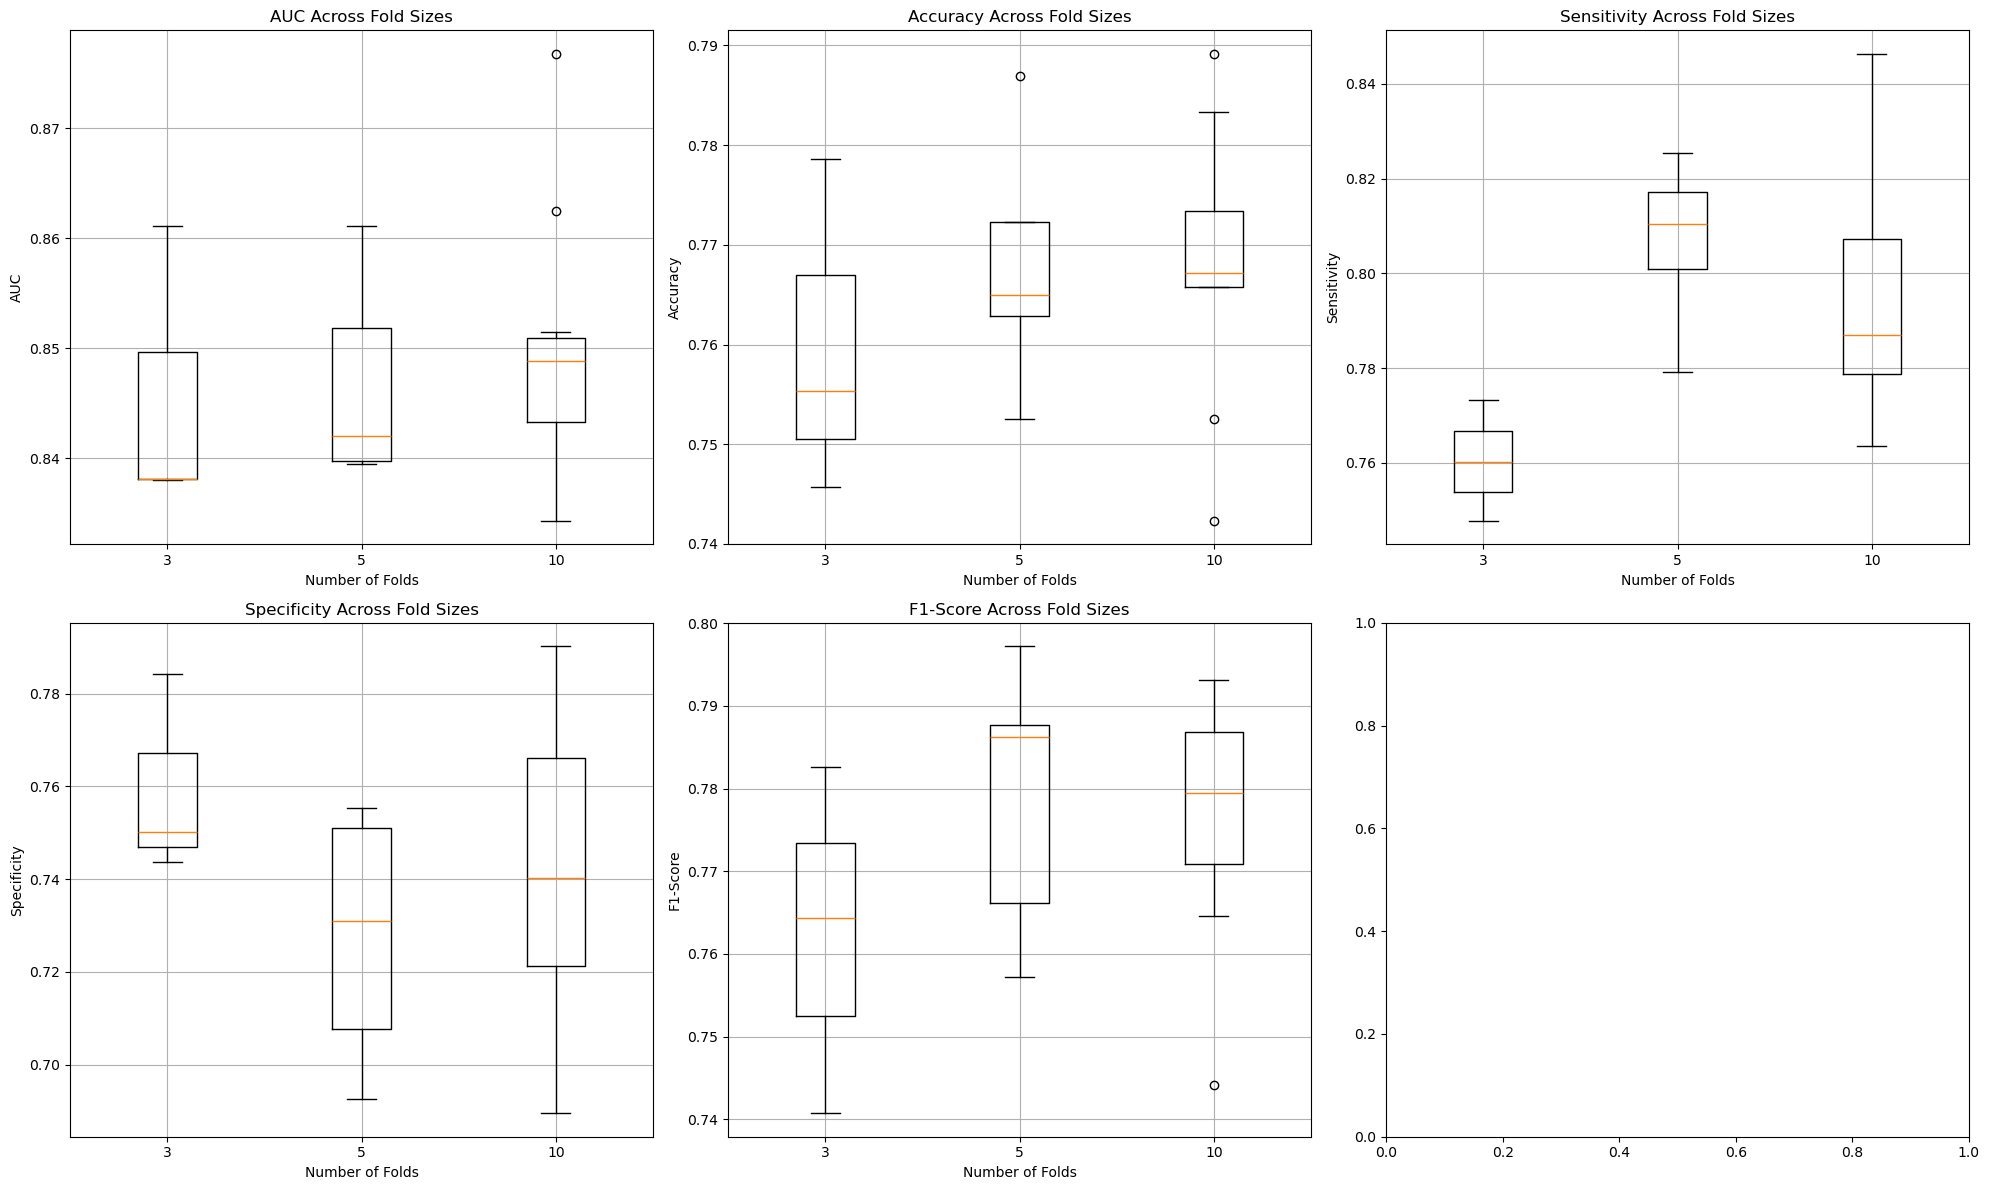

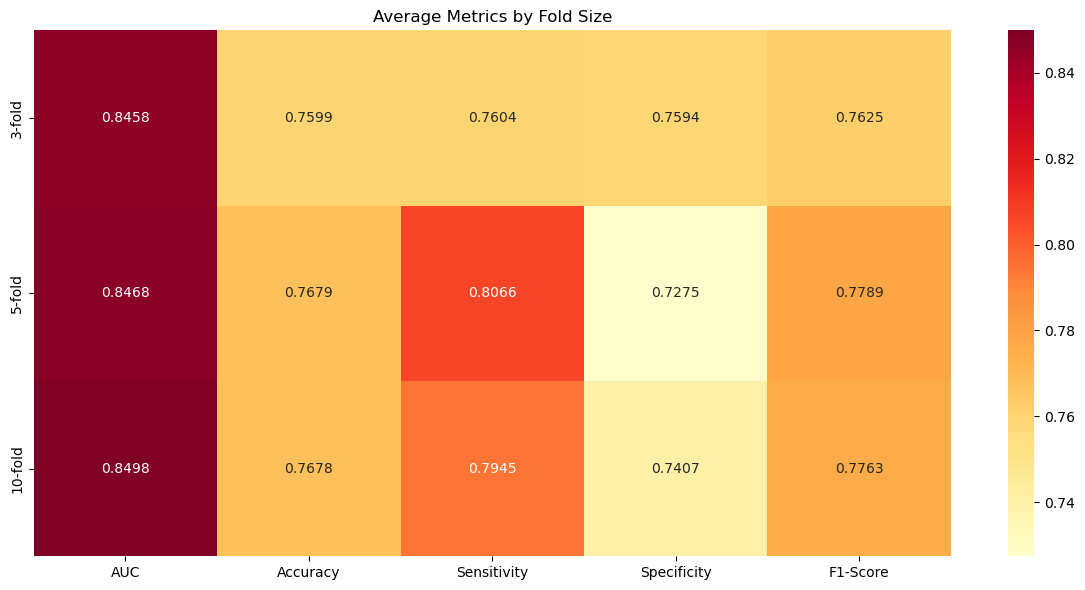

In [15]:
# Function to perform k-fold cross validation
def perform_kfold_cv(X, y, k_folds, num_epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_results = []
    
    print(f"\nPerforming {k_folds}-fold cross validation...")
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
        print(f"\nFold {fold+1}/{k_folds}")
        
        # Split data
        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)
        
        # Convert to tensors
        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32)
        
        # Create datasets and dataloaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32)
        
        # Initialize model, criterion, and optimizer
        model = TensorFlowToPyTorchModel(input_features=1408).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
        
        best_val_metrics = None
        best_model_weights = None
        
        # Training loop
        for epoch in range(num_epochs):
            # Train
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
            
            # Validate with full metrics
            val_outputs = []
            val_labels = []
            
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)
                    val_outputs.extend(torch.sigmoid(outputs).cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())
            
            val_outputs = np.array(val_outputs)
            val_labels = np.array(val_labels)
            val_preds = (val_outputs > 0.5).astype(int)
            
            # Calculate metrics
            tn, fp, fn, tp = confusion_matrix(val_labels, val_preds).ravel()
            val_acc = (tp + tn) / (tp + tn + fp + fn)
            val_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            val_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            val_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            val_f1 = 2 * (val_precision * val_sensitivity) / (val_precision + val_sensitivity) if (val_precision + val_sensitivity) > 0 else 0
            val_auc = roc_auc_score(val_labels, val_outputs)
            
            # Learning rate scheduling
            scheduler.step(val_loss)
            
            # Save best model based on AUC
            if best_val_metrics is None or val_auc > best_val_metrics['auc']:
                best_val_metrics = {
                    'loss': val_loss,
                    'accuracy': val_acc,
                    'sensitivity': val_sensitivity,
                    'specificity': val_specificity,
                    'f1_score': val_f1,
                    'auc': val_auc,
                    'confusion_matrix': {'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}
                }
                best_model_weights = model.state_dict().copy()
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] Val AUC: {val_auc:.4f}")
        
        # Store fold results
        fold_results.append({
            'fold': fold + 1,
            'metrics': best_val_metrics
        })
        
        print(f"Fold {fold+1} completed. Best validation AUC: {best_val_metrics['auc']:.4f}")
    
    return fold_results

# Test different k-fold sizes
k_fold_sizes = [3, 5, 10]
all_results = {}

# Create figure for subplots
plt.figure(figsize=(20, 15))
metric_names = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity', 'F1-Score']

for k in k_fold_sizes:
    print(f"\n{'='*50}")
    print(f"Starting {k}-fold cross validation")
    print(f"{'='*50}")
    
    results = perform_kfold_cv(X, y, k)
    all_results[k] = results
    
    # Calculate and display average metrics with standard deviation
    metrics_summary = {
        'auc': [r['metrics']['auc'] for r in results],
        'accuracy': [r['metrics']['accuracy'] for r in results],
        'sensitivity': [r['metrics']['sensitivity'] for r in results],
        'specificity': [r['metrics']['specificity'] for r in results],
        'f1_score': [r['metrics']['f1_score'] for r in results]
    }
    
    print(f"\nDetailed results for {k}-fold cross validation:")
    print("-" * 40)
    print("Metric      Mean ± Std Dev    Min    Max")
    print("-" * 40)
    
    for metric in metric_names:
        values = metrics_summary[metric.lower().replace('-', '_')]
        print(f"{metric:<10} {np.mean(values):.4f} ± {np.std(values):.4f}  {min(values):.4f}  {max(values):.4f}")

# Plot comprehensive results
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

# Plot boxplots for each metric
for i, metric in enumerate(metric_names):
    metric_key = metric.lower().replace('-', '_')
    data = [
        [r['metrics'][metric_key] for r in all_results[k]]
        for k in k_fold_sizes
    ]
    
    axes[i].boxplot(data, labels=k_fold_sizes)
    axes[i].set_title(f'{metric} Across Fold Sizes')
    axes[i].set_xlabel('Number of Folds')
    axes[i].set_ylabel(metric)
    axes[i].grid(True)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Create a summary heatmap
summary_data = []
for k in k_fold_sizes:
    row = []
    for metric in metric_names:
        metric_key = metric.lower().replace('-', '_')
        values = [r['metrics'][metric_key] for r in all_results[k]]
        row.append(np.mean(values))
    summary_data.append(row)

plt.figure(figsize=(12, 6))
sns.heatmap(summary_data, 
            annot=True, 
            fmt='.4f', 
            cmap='YlOrRd',
            xticklabels=metric_names,
            yticklabels=[f'{k}-fold' for k in k_fold_sizes])
plt.title('Average Metrics by Fold Size')
plt.tight_layout()
plt.show()

Summary Statistics Across All Folds:
               Mean     Std     Min     Max  Median
AUC          0.8483  0.0108  0.8343  0.8768  0.8477
Accuracy     0.7665  0.0130  0.7423  0.7892  0.7657
Sensitivity  0.7922  0.0244  0.7477  0.8464  0.7871
Specificity  0.7401  0.0292  0.6895  0.7903  0.7432
F1-Score     0.7747  0.0156  0.7407  0.7972  0.7795

Breakdown by Fold Size:


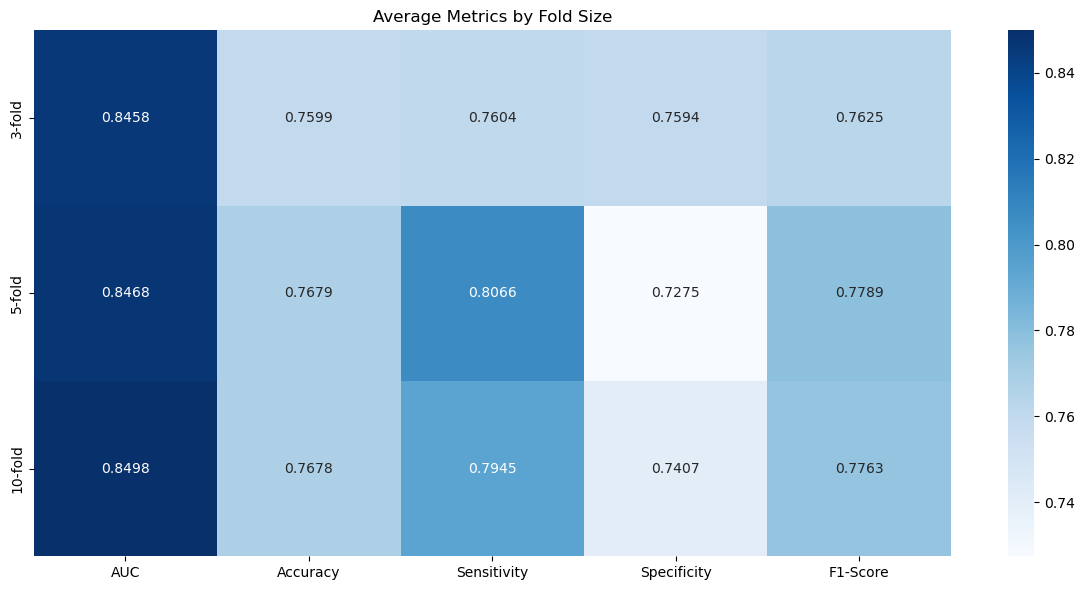


3-Fold Cross Validation Results:
----------------------------------------
               Mean     Std
AUC          0.8458  0.0109
Accuracy     0.7599  0.0138
Sensitivity  0.7604  0.0104
Specificity  0.7594  0.0177
F1-Score     0.7625  0.0171

5-Fold Cross Validation Results:
----------------------------------------
               Mean     Std
AUC          0.8468  0.0084
Accuracy     0.7679  0.0114
Sensitivity  0.8066  0.0159
Specificity  0.7275  0.0243
F1-Score     0.7789  0.0148

10-Fold Cross Validation Results:
----------------------------------------
               Mean     Std
AUC          0.8498  0.0116
Accuracy     0.7678  0.0128
Sensitivity  0.7945  0.0224
Specificity  0.7407  0.0308
F1-Score     0.7763  0.0136


In [17]:
# Create comprehensive summary statistics
summary_stats = {}
for metric in metric_names:
    metric_key = metric.lower().replace('-', '_')
    all_values = []
    for k in k_fold_sizes:
        values = [r['metrics'][metric_key] for r in all_results[k]]
        all_values.extend(values)
    
    summary_stats[metric] = {
        'Mean': np.mean(all_values),
        'Std': np.std(all_values),
        'Min': np.min(all_values),
        'Max': np.max(all_values),
        'Median': np.median(all_values)
    }

# Create and display summary statistics table
summary_df = pd.DataFrame(summary_stats).transpose()
summary_df = summary_df.round(4)

print("Summary Statistics Across All Folds:")
print("=" * 80)
print(summary_df)
print("\nBreakdown by Fold Size:")
print("=" * 80)

# Create heatmap with blue color scheme
plt.figure(figsize=(12, 6))
sns.heatmap(summary_data, 
            annot=True, 
            fmt='.4f', 
            cmap='Blues',
            xticklabels=metric_names,
            yticklabels=[f'{k}-fold' for k in k_fold_sizes])
plt.title('Average Metrics by Fold Size')
plt.tight_layout()
plt.show()

# Display detailed statistics for each fold size
for k in k_fold_sizes:
    print(f"\n{k}-Fold Cross Validation Results:")
    print("-" * 40)
    metrics_summary = {
        metric: {
            'Mean': np.mean([r['metrics'][metric.lower().replace('-', '_')] for r in all_results[k]]),
            'Std': np.std([r['metrics'][metric.lower().replace('-', '_')] for r in all_results[k]])
        }
        for metric in metric_names
    }
    fold_df = pd.DataFrame(metrics_summary).transpose()
    fold_df.columns = ['Mean', 'Std']
    fold_df = fold_df.round(4)
    print(fold_df)

In [16]:
model.eval()
test_loss, metrics, test_labels, test_probs = validate_epoch(
    model, test_loader, criterion, device
)

print(f"\nFinal Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {metrics['accuracy']:.4f}")
print(f"Test AUC: {metrics['auc']:.4f}")
print(f"Sensitivity: {metrics['sensitivity']:.4f}")
print(f"Specificity: {metrics['specificity']:.4f}")
print(f"F1-Score: {metrics['f1_score']:.4f}")

# Create a more detailed visualization of the metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC', 'Sensitivity', 'Specificity', 'F1-Score'],
    'Value': [
        metrics['accuracy'],
        metrics['auc'],
        metrics['sensitivity'],
        metrics['specificity'],
        metrics['f1_score']
    ]
})

# Plot metrics as a bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(metrics_df['Metric'], metrics_df['Value'])
plt.title('Model Performance Metrics')
plt.ylim(0, 1)
plt.grid(True, axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {metrics["auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CT Scan Classification')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix with percentages
cm = confusion_matrix(test_labels, (np.array(test_probs) > 0.5).astype(int))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Abnormal', 'Normal'],
            yticklabels=['Abnormal', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Counts)')
plt.show()

# Normalized Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Abnormal', 'Normal'],
            yticklabels=['Abnormal', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Normalized)')
plt.show()

ValueError: too many values to unpack (expected 4)